In [ ]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems

In [ ]:
function select(values,val,v1)
    index=findall(x->x==values,val)
    vec = v1[:,index]
    u = vec[1:N_cheb-1,1]
    v = vec[N_cheb:2*(N_cheb-1),1]
    w = vec[2*(N_cheb)-1:3*(N_cheb-1),1]
    u = [0;u;0]
    v = [0;v;0]
    w = [0;w;0]
    return vec,u,v,w
end

In [335]:
N_cheb = 99
Re = 500
R = Re
Mr = 0.04
Ma = Mr/R
Tw = 1
gamma = 1.4
sigma = 0.72
omega = 0
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T ;

In [343]:
netual_cur

4×3 Matrix{ComplexF64}:
 501.0+0.0im     0.0+0.0im        0.0+0.0im
 500.0+0.0im   0.031+0.0im  0.0653126-0.000153798im
 489.0+0.0im   0.031+0.0im   0.068758-0.000663695im
 476.0+0.0im  0.0311+0.0im  0.0690546-7.87457e-6im

In [340]:
netual_cur = [501 0 0]
for be = 0.02:0.0005:0.1
    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = 0.01, neigs = 1,maxit = 500);
    point = filter(x -> -0.01 < imag(x) < 0 && real(x)>0.05, eigval)
    if point !=  []
        println("start_beta = ",be)
        println("eigenvalue = ",point)
        break
    end
end
cacu_point = [Re be point]
netual_cur = [netual_cur;cacu_point]
@showprogress for be = real(cacu_point[2]) : 0.0001 : 0.15

    point = cacu_point[3]
    point_temp = []
    if real(netual_cur[end-1,1]) > real(netual_cur[end,1])

        while point != []

            Ma = Mr/R
            u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
            H,T = T_ca(Mr,f,q,w0,gamma,Tw)
            F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
            lam = - (2/3) * T
            kappa = (1/sigma) * T ;
            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = cacu_point[3] , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x -> - 0.01 < imag(x) < 0 && real(x)>0.05, eigval)
            point_temp = [point_temp;point]
            global R -= 1

        end

        cacu_point = [R be point_temp[end,1]]
        netual_cur = [netual_cur;cacu_point]
        
    end

    if real(netual_cur[end-1,1]) < real(netual_cur[end,1])

        while point != []

            Ma = Mr/R
            u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb)
            H,T = T_ca(Mr,f,q,w0,gamma,Tw)
            F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
            lam = - (2/3) * T
            kappa = (1/sigma) * T ;
            A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = cacu_point[3] , neigs = 1 ,maxit = 500,tol=1e-10)
            point = filter(x -> - 0.01 < imag(x) < 0 && real(x)>0.05, eigval)
            point_temp = [point_temp;point]

            global R += 1

        end

        cacu_point = [R be point_temp[end,1]]
        netual_cur = [netual_cur;cacu_point]

    end

end 

BoundsError: BoundsError: attempt to access 0-element Vector{Any} at index [0, 1]

In [320]:
netual_cur = [netual_cur;cacu_point]

134×3 Matrix{ComplexF64}:
 501.0+0.0im     0.0+0.0im        0.0+0.0im
 500.0+0.0im   0.031+0.0im    0.06594-0.000639717im
 499.0+0.0im   0.031+0.0im  0.0688035-0.00116982im
 498.0+0.0im  0.0311+0.0im  0.0691142-0.00119569im
 497.0+0.0im  0.0312+0.0im  0.0694172-0.00117519im
 496.0+0.0im  0.0313+0.0im   0.069671-0.00124525im
 495.0+0.0im  0.0314+0.0im  0.0700304-0.000959182im
 494.0+0.0im  0.0315+0.0im   0.070396-0.00104797im
 493.0+0.0im  0.0316+0.0im  0.0707494-0.00139264im
 492.0+0.0im  0.0317+0.0im  0.0709696-0.00127578im
      ⋮                     
 350.0+0.0im  0.0433+0.0im    0.10773-0.000866202im
 346.0+0.0im  0.0434+0.0im   0.107356-0.0020136im
 343.0+0.0im  0.0435+0.0im   0.111145-6.22234e-5im
 334.0+0.0im  0.0436+0.0im   0.108477-0.00405276im
 331.0+0.0im  0.0437+0.0im   0.112778-0.00148025im
 330.0+0.0im  0.0438+0.0im   0.111901-0.00214437im
 326.0+0.0im  0.0439+0.0im   0.113293-0.00175717im
 319.0+0.0im   0.044+0.0im   0.107883-0.00148338im
 319.0+0.0im   0.044+0.0im   0.1

In [123]:
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Vonkarmen.txt",N_cheb,omega,be,R,1,2)
nep1 = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep1,σ = 0.01, neigs = 30,maxit = 500);
point = filter(x -> -0.01 < imag(x) < 0.001, eigval)

ComplexF64[]

In [182]:
be = 0.04
A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = 0.05-0.001im, neigs = 1,maxit = 500);
point = filter(x -> -0.1 < imag(x) < 0.001, eigval)

1-element Vector{ComplexF64}:
 -0.0023168133951529425 - 0.039093120975809754im

In [ ]:
eig = [empty! empty!]
@showprogress for be = 0.04:0.001:0.14
    
    A0,A1,A2 = Spatial_mode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = 0.38 + 0.0001im, neigs = 3,maxit = 500);
    point = filter(x -> -0.001 < imag(x) < 0.001, eigval)
    if point == []
        eig = [eig;[be 0]]
    else
        eig = [eig;[be point[1]]]
    end
end

In [ ]:
for be  

In [ ]:
vec,u,v,w = select(point[1],point[1],eigvec)

In [ ]:
plot(x,abs.(u),label="eigenvec_u")
plot!(x,abs.(v),label="eigenvec_v")
plot!(x,abs.(w),label="eigenvec_w",xlims=[0,10],ylims=[0,0.251])

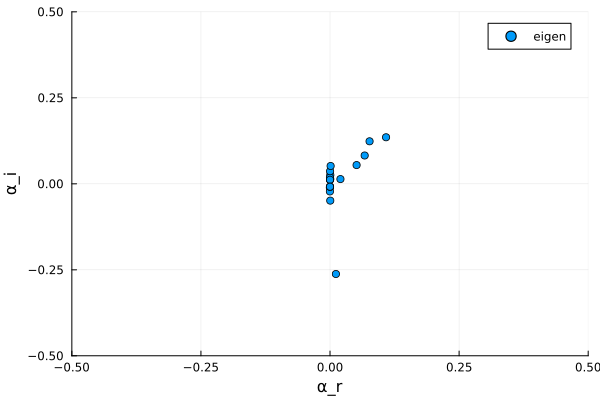

In [147]:
scatter(real(eigval),imag(eigval),xlims=[-0.5,0.5],ylims=[-0.5,0.5],xlabel ="α_r",ylabel="α_i",label="eigen")